In[1]:

In [2]:
#!/usr/bin/env python
# coding: utf-8

In[2]:

In [1]:
import scipy.io
import os
import sys
import numpy as np
from scipy.interpolate import interp1d
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sbi import utils as sbi_utils
from sbi.inference import SNPE
from sbi.utils.get_nn_models import posterior_nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Ask the user to target the name format

In[3]:

In [2]:
name_format = "SBI_test"
print("Note: use results8.mat which has 10000 datasets; B only has positive Z values")
file_path = os.path.join('MATLAB_DATA', 'results8.mat')  # Replace with your actual file path
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

Note: use results8.mat which has 10000 datasets; B only has positive Z values


In[128]:

In [3]:
import os
import scipy.io
import h5py
import numpy as np
from scipy.interpolate import interp1d

Define the list of files that should be processed as HDF5 files

In [4]:
h5_file_numbers = {3, 6, 7, 9}

Function to load data from .h5 file

In [5]:
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to load data from .mat file

In [6]:
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to resample and smooth data

In [7]:
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

Function to process data

In [8]:
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

Main function to determine the type of file and load data accordingly

In [9]:
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

Example usage

In [10]:
B_MAG_data, EDC_MAG_data, X_data, I_data = load_and_process_file(file_path)

Processing results8.mat as a .mat file...


Data is now loaded and processed.

In [11]:
print("Data processing completed.")

Data processing completed.


In [12]:
means = np.mean(I_data, axis=0)
stds = np.std(I_data, axis=0)

In[15]:

In [13]:
start_index = 0
end_index = I_data.shape[1] - 1

In[16]:

In [14]:
for i in range(I_data.shape[1]):
    if stds[i] >= 0.01:
        start_index = i
        break

In[17]:

In [15]:
for i in range(I_data.shape[1] - 1, -1, -1):
    if stds[i] >= 0.01:
        end_index = i
        break

In[18]:

In [20]:
I_data_filtered = I_data[:, start_index:end_index + 1]
X_data_filtered = X_data[:, start_index:end_index + 1]
means_filtered = means[start_index:end_index + 1]
stds_filtered = stds[start_index:end_index + 1]
print(f"Data filtered from column {start_index} to {end_index}.")

Data filtered from column 94 to 1103.


Normalize the data

In[19]:

In [17]:
normalized_I = (I_data_filtered - means_filtered) / stds_filtered

In[20]:

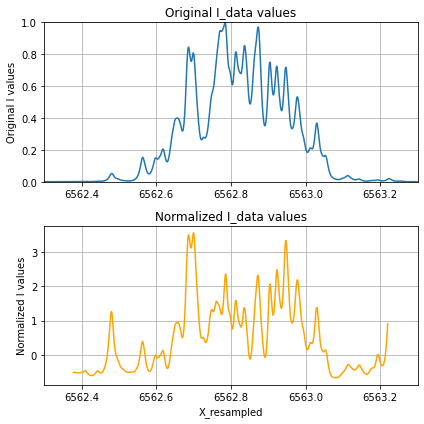

In [21]:
import matplotlib.pyplot as plt
# Row 10 of original and normalized data
index = 600
original_row = I_data[index]
X_resampled = X_data[index]
normalized_row = normalized_I[index]
X_resampled_filtered = X_data_filtered[index]

plt.figure(figsize=(6, 6))

plt.subplot(2, 1, 1)
plt.plot(X_resampled, original_row, label='Original I_data')
plt.title('Original I_data values')
plt.ylabel('Original I values')
plt.ylim(0, 1)
plt.xlim(6562.3, 6563.3)
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(X_resampled_filtered, normalized_row, label='Normalized I_data', color='orange')
plt.title('Normalized I_data values')
plt.xlabel('X_resampled')
plt.ylabel('Normalized I values')
plt.xlim(6562.3, 6563.3)
plt.grid(True)

plt.tight_layout()
plt.show()

Extract the 10th column (index 9 in zero-indexed Python)

In [23]:
index = 400
original_column = I_data[:, index]
normalized_column = normalized_I[:, index]

Create the figure with two subplots

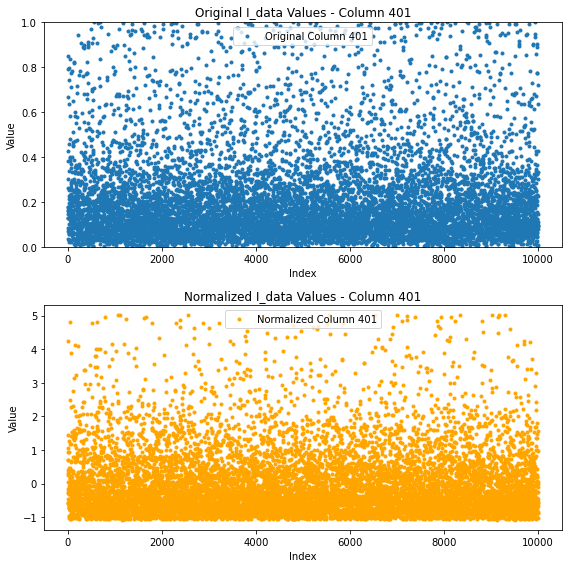

In [24]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(original_column, '.', label=f'Original Column {index+1}')
plt.title(f'Original I_data Values - Column {index+1}')
plt.ylim(0, 1)
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(normalized_column, '.', label=f'Normalized Column {index+1}', color='orange')
plt.title(f'Normalized I_data Values - Column {index+1}')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

In[22]:

In [ ]:
input_data = normalized_I

Normalize target and target data

In[24]:

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Assuming B_MAG_data and EDC_MAG_data are loaded as NumPy arrays
# B3 is B_MAG_data[:, 2], and EDC_MAG_data consists of E1, E2, E3
B1 = B_MAG_data[:, 0].reshape(-1, 1)
B2= B_MAG_data[:, 1].reshape(-1, 1)
B3 = B_MAG_data[:, 2].reshape(-1, 1)  # B3 component
E1 = EDC_MAG_data[:, 0].reshape(-1, 1)  # E1 component
E2 = EDC_MAG_data[:, 1].reshape(-1, 1)  # E2 component
E3 = EDC_MAG_data[:, 2].reshape(-1, 1)  # E3 component

# Create separate MinMaxScaler instances for each component
scaler_B1 = MinMaxScaler(feature_range=(0, 1))
scaler_B2 = MinMaxScaler(feature_range=(0, 1))
scaler_B3 = MinMaxScaler(feature_range=(0, 1))
scaler_E1 = MinMaxScaler(feature_range=(0, 1))
scaler_E2 = MinMaxScaler(feature_range=(0, 1))
scaler_E3 = MinMaxScaler(feature_range=(0, 1))

# Fit and transform each component separately
B1_scaled = scaler_B1.fit_transform(B1)
B2_scaled = scaler_B2.fit_transform(B2)
B3_scaled = scaler_B3.fit_transform(B3)
E1_scaled = scaler_E1.fit_transform(E1)
E2_scaled = scaler_E2.fit_transform(E2)
E3_scaled = scaler_E3.fit_transform(E3)

# Recombine the scaled components back into target_data
target_data = np.hstack((B1_scaled, B2_scaled, B3_scaled, E1_scaled, E2_scaled, E3_scaled))

# Now, target_data_scaled contains B3, E1, E2, E3 all scaled between 0 and 1


Convert to PyTorch tensors

In[25]:

In [ ]:
target_data_tensor = torch.tensor(target_data, dtype=torch.float32)
input_data_tensor = torch.tensor(input_data, dtype=torch.float32)

Split into training and testing sets

In[26]:

In [ ]:
target_data_train, target_data_test, input_data_train, input_data_test = train_test_split(
    target_data, input_data, test_size=0.2, random_state=42
)

In[27]:

In [ ]:
target_data_train_tensor = torch.tensor(target_data_train, dtype=torch.float32)
target_data_test_tensor = torch.tensor(target_data_test, dtype=torch.float32)
input_data_train_tensor = torch.tensor(input_data_train, dtype=torch.float32)
input_data_test_tensor = torch.tensor(input_data_test, dtype=torch.float32)

In[28]:

In [ ]:
print("Data organized.", flush=True)

Define prior for SNPE

In[29]:

In [ ]:
prior_min = torch.tensor([target_data_tensor.min().item()] * target_data_tensor.shape[1])
prior_max = torch.tensor([target_data_tensor.max().item()] * target_data_tensor.shape[1])
margin = 0.1 * (prior_max - prior_min)
prior = sbi_utils.BoxUniform(low=prior_min - margin, high=prior_max + margin)

Train the SNPE model

In[30]:

In [ ]:
print("Start training.", flush=True)

Start training.


In[31]:

In [ ]:
neural_net = posterior_nn(model='nsf', hidden_features=64, num_transforms=10)
inference = NPE(prior=prior, density_estimator=neural_net)

In[ ]:

In [ ]:
inference.append_simulations(target_data_train_tensor, input_data_train_tensor)
density_estimator = inference.train(max_num_epochs=200, learning_rate=0.001, training_batch_size=128)

 Training neural network. Epochs trained: 11

In[ ]:

In [ ]:
posterior = inference.build_posterior(density_estimator)

In[ ]:

In [ ]:
print("Training done.", flush=True)

Save the model

In[ ]:

In [ ]:
posterior_path = os.path.join("/home/botingl/machine learning", generate_filename("posterior", "pt"))
density_estimator_path = os.path.join("/home/botingl/machine learning", generate_filename("density_estimator", "pt"))

In[ ]:

In [ ]:
torch.save(posterior, posterior_path)
torch.save(density_estimator.state_dict(), density_estimator_path)

In[ ]:

In [ ]:
print("Model saved successfully.")

Load the saved model

In[ ]:

In [ ]:
posterior = torch.load(posterior_path)
print("Model loaded successfully.")

Evaluate the model on the training set

In[ ]:

In [ ]:
print("Start to evaluate the training set.", flush=True)

In[ ]:

In [ ]:
train_subset_indices = np.random.choice(len(input_data_train), size=1000, replace=False)
train_input_data_subset = input_data_train[train_subset_indices]
train_target_data_subset = target_data_train[train_subset_indices]

In [ ]:
import sys
import numpy as np
from tqdm import tqdm

# Generate predictions for the test set
predictions_train = []
for i in tqdm(range(len(train_input_data_subset)), desc="Processing samples", leave=True, file=sys.stdout):
    train_input = train_input_data_subset[i]  # This is the X and I for this test sample
    predicted_posterior = posterior.sample((1000,), x=train_input, show_progress_bars=False)  # Disable internal progress bars
    
    # Extract mean prediction for B and E
    predicted_mean = predicted_posterior.mean(dim=0)
    predictions_train.append(predicted_mean)
    
    sys.stdout.flush()  # Manually flush output

# Convert predictions to numpy array
predictions_train = torch.stack(predictions).detach().numpy()

print("Evaluation done.", flush=True)

Processing samples:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/botingl/miniconda3/envs/portal_new/lib/python3.8/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at  ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2189.)
  outputs, _ = torch.triangular_solve(


Processing samples:   0%|          | 4/1000 [00:38<2:40:22,  9.66s/it]


KeyboardInterrupt: 

In [ ]:
mae_train = mean_absolute_error(train_target_data_subset, predictions_train)
rmse_train = np.sqrt(mean_squared_error(train_target_data_subset, predictions_train))
r2_train = r2_score(train_target_data_subset, predictions_train)
nrmse_train = np.sqrt(np.mean((train_target_data_subset - predictions_train) ** 2)) / (train_target_data_subset.max() - train_target_data_subset.min())

In [ ]:
print(f'NRMSE (Train): {nrmse_train:.2f}')
print(f'Mean Absolute Error (MAE, Train): {mae_train}')
print(f'Root Mean Squared Error (RMSE, Train): {rmse_train}')
print(f'R^2 Score (Train): {r2_train}')

Scale back the predicted values to original range

In [ ]:
B_pred_train = np.column_stack((
    scaler_B1.inverse_transform(predictions_train[:, 0].reshape(-1, 1)),
    scaler_B2.inverse_transform(predictions_train[:, 1].reshape(-1, 1)),
    scaler_B3.inverse_transform(predictions_train[:, 2].reshape(-1, 1))
))

In [ ]:
E_pred_train = np.column_stack((
    scaler_E1.inverse_transform(predictions_train[:, 3].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_train[:, 4].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_train[:, 5].reshape(-1, 1))
))

Scale back the true values to original range

In [ ]:
B_true_train = np.column_stack((
    scaler_B1.inverse_transform(train_target_data_subset[:, 0].reshape(-1, 1)),
    scaler_B2.inverse_transform(train_target_data_subset[:, 1].reshape(-1, 1)),
    scaler_B3.inverse_transform(train_target_data_subset[:, 2].reshape(-1, 1))
))

In [ ]:
E_true_train = np.column_stack((
    scaler_E1.inverse_transform(train_target_data_subset[:, 3].reshape(-1, 1)),
    scaler_E2.inverse_transform(train_target_data_subset[:, 4].reshape(-1, 1)),
    scaler_E3.inverse_transform(train_target_data_subset[:, 5].reshape(-1, 1))
))

Calculate evaluation metrics separately for each B and E component for the train set

In [ ]:
mae_train_B1 = mean_absolute_error(B_true_train[:, 0], B_pred_train[:, 0])
rmse_train_B1 = np.sqrt(mean_squared_error(B_true_train[:, 0], B_pred_train[:, 0]))
r2_train_B1 = r2_score(B_true_train[:, 0], B_pred_train[:, 0])

In [ ]:
mae_train_B2 = mean_absolute_error(B_true_train[:, 1], B_pred_train[:, 1])
rmse_train_B2 = np.sqrt(mean_squared_error(B_true_train[:, 1], B_pred_train[:, 1]))
r2_train_B2 = r2_score(B_true_train[:, 1], B_pred_train[:, 1])

In [ ]:
mae_train_B3 = mean_absolute_error(B_true_train[:, 2], B_pred_train[:, 2])
rmse_train_B3 = np.sqrt(mean_squared_error(B_true_train[:, 2], B_pred_train[:, 2]))
r2_train_B3 = r2_score(B_true_train[:, 2], B_pred_train[:, 2])

E1

In [ ]:
mae_train_E1 = mean_absolute_error(E_true_train[:, 0], E_pred_train[:, 0])
rmse_train_E1 = np.sqrt(mean_squared_error(E_true_train[:, 0], E_pred_train[:, 0]))
r2_train_E1 = r2_score(E_true_train[:, 0], E_pred_train[:, 0])

E2

In [ ]:
mae_train_E2 = mean_absolute_error(E_true_train[:, 1], E_pred_train[:, 1])
rmse_train_E2 = np.sqrt(mean_squared_error(E_true_train[:, 1], E_pred_train[:, 1]))
r2_train_E2 = r2_score(E_true_train[:, 1], E_pred_train[:, 1])

E3

In [ ]:
mae_train_E3 = mean_absolute_error(E_true_train[:, 2], E_pred_train[:, 2])
rmse_train_E3 = np.sqrt(mean_squared_error(E_true_train[:, 2], E_pred_train[:, 2]))
r2_train_E3 = r2_score(E_true_train[:, 2], E_pred_train[:, 2])

Print metrics for train set

In [ ]:
print(f"Train MAE - B1: {mae_train_B1}, B2: {mae_train_B2}, B3: {mae_train_B3}")
print(f"Train RMSE - B1: {rmse_train_B1}, B2: {rmse_train_B2}, B3: {rmse_train_B3}")
print(f"Train R2 - B1: {r2_train_B1}, B2: {r2_train_B2}, B3: {r2_train_B3}")

In [ ]:
print(f"Train MAE - E1: {mae_train_E1}, E2: {mae_train_E2}, E3: {mae_train_E3}")
print(f"Train RMSE - E1: {rmse_train_E1}, E2: {rmse_train_E2}, E3: {rmse_train_E3}")
print(f"Train R2 - E1: {r2_train_E1}, E2: {r2_train_E2}, E3: {r2_train_E3}")

Save evaluation metrics to a text file

In[147]:

In [ ]:
metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_train", "txt"))
with open(metrics_train_file, "w") as f:
    f.write(f"Mean Absolute Error (MAE): {mae_train}\n")
    f.write(f"Root Mean Squared Error (RMSE): {rmse_train}\n")
    f.write(f"R^2 Score: {r2_train}\n")
    f.write(f"Normalized RMSE (NRMSE): {nrmse_train}\n")

Plot the true vs. predicted B and E values for the training set

In [ ]:
plt.figure(figsize=(15, 10))
for i in range(3):
    plt.subplot(2, 3, i+1)
    plt.scatter(B_true_train[:, i],  B_pred_train[:, i], alpha=0.5)
    plt.xlabel(f'True B[{i+1}]')
    plt.ylabel(f'Predicted B[{i+1}]')
    plt.title(f'True vs. Predicted B[{i+1}]')

for i in range(3):
    plt.subplot(2, 3, i+4)
    plt.scatter(E_true_train[:, i],  E_pred_train[:, i], alpha=0.5)
    plt.xlabel(f'True E[{i+1}]')
    plt.ylabel(f'Predicted E[{i+1}]')
    plt.title(f'True vs. Predicted E[{i+1}]')

plt.tight_layout()
figure_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_train", "png"))
plt.savefig(figure_file, dpi=300, facecolor='white')
plt.show()
plt.close()


In[148]:

In[149]:

In [ ]:
import sys
import numpy as np
from tqdm import tqdm

# Generate predictions for the test set
predictions_test = []
for i in tqdm(range(len(input_data_test_data_test)), desc="Processing samples", leave=True, file=sys.stdout):
    test_input = input_data_test[i]  # This is the X and I for this test sample
    predicted_posterior = posterior.sample((1000,), x=test_input, show_progress_bars=False)  # Disable internal progress bars
    
    # Extract mean prediction for B and E
    predicted_mean = predicted_posterior.mean(dim=0)
    predictions_test.append(predicted_mean)
    
    sys.stdout.flush()  # Manually flush output

# Convert predictions to numpy array
predictions_test = torch.stack(predictions).detach().numpy()

print("Evaluation done.", flush=True)

In [ ]:
mae_test = mean_absolute_error(target_test_scaled, predictions_test)
rmse_test = np.sqrt(mean_squared_error(target_test_scaled, predictions_test))
r2_test = r2_score(target_test_scaled, predictions_test)
nrmse_test = np.sqrt(np.mean((target_test_scaled - predictions_test) ** 2)) / (target_test_scaled.max() - target_test_scaled.min())

In [ ]:
print(f'NRMSE (Test): {nrmse_test:.2f}')
print(f'Mean Absolute Error (MAE, Test): {mae_test}')
print(f'Root Mean Squared Error (RMSE, Test): {rmse_test}')
print(f'R^2 Score (Test): {r2_test}')

Scale back the predicted values to original range for the test data

In [ ]:
B_pred_test = np.column_stack((
    scaler_B1.inverse_transform(predictions_test[:, 0].reshape(-1, 1)),
    scaler_B2.inverse_transform(predictions_test[:, 1].reshape(-1, 1)),
    scaler_B3.inverse_transform(predictions_test[:, 2].reshape(-1, 1))
))

In [ ]:
E_pred_test = np.column_stack((
    scaler_E1.inverse_transform(predictions_test[:, 3].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_test[:, 4].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_test[:, 5].reshape(-1, 1))
))

Scale back the true values to original range for the test data

In [ ]:
B_true_test = np.column_stack((
    scaler_B1.inverse_transform(target_test_scaled[:, 0].reshape(-1, 1)),
    scaler_B2.inverse_transform(target_test_scaled[:, 1].reshape(-1, 1)),
    scaler_B3.inverse_transform(target_test_scaled[:, 2].reshape(-1, 1))
))

In [ ]:
E_true_test = np.column_stack((
    scaler_E1.inverse_transform(target_test_scaled[:, 3].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_test_scaled[:, 4].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_test_scaled[:, 5].reshape(-1, 1))
))

Calculate evaluation metrics separately for B3 and E components for the test set

In [ ]:
mae_test_B1 = mean_absolute_error(B_true_test[:, 0], B_pred_test[:, 0])
rmse_test_B1 = np.sqrt(mean_squared_error(B_true_test[:, 0], B_pred_test[:, 0]))
r2_test_B1 = r2_score(B_true_test[:, 0], B_pred_test[:, 0])

In [ ]:
mae_test_B2 = mean_absolute_error(B_true_test[:, 1], B_pred_test[:, 1])
rmse_test_B2 = np.sqrt(mean_squared_error(B_true_test[:, 1], B_pred_test[:, 1]))
r2_test_B2 = r2_score(B_true_test[:, 1], B_pred_test[:, 1])

In [ ]:
mae_test_B3 = mean_absolute_error(B_true_test[:, 2], B_pred_test[:, 2])
rmse_test_B3 = np.sqrt(mean_squared_error(B_true_test[:, 2], B_pred_test[:, 2]))
r2_test_B3 = r2_score(B_true_test[:, 2], B_pred_test[:, 2])

E1

In [ ]:
mae_test_E1 = mean_absolute_error(E_true_test[:, 0], E_pred_test[:, 0])
rmse_test_E1 = np.sqrt(mean_squared_error(E_true_test[:, 0], E_pred_test[:, 0]))
r2_test_E1 = r2_score(E_true_test[:, 0], E_pred_test[:, 0])

E2

In [ ]:
mae_test_E2 = mean_absolute_error(E_true_test[:, 1], E_pred_test[:, 1])
rmse_test_E2 = np.sqrt(mean_squared_error(E_true_test[:, 1], E_pred_test[:, 1]))
r2_test_E2 = r2_score(E_true_test[:, 1], E_pred_test[:, 1])

E3

In [ ]:
mae_test_E3 = mean_absolute_error(E_true_test[:, 2], E_pred_test[:, 2])
rmse_test_E3 = np.sqrt(mean_squared_error(E_true_test[:, 2], E_pred_test[:, 2]))
r2_test_E3 = r2_score(E_true_test[:, 2], E_pred_test[:, 2])

Print metrics for test set

In [ ]:
print(f"Test MAE - B1: {mae_test_B1}, B2: {mae_test_B2}, B3: {mae_test_B3}")
print(f"Test RMSE - B1: {rmse_test_B1}, B2: {rmse_test_B2}, B3: {rmse_test_B3}")
print(f"Test R2 - B1: {r2_test_B1}, B2: {r2_test_B2}, B3: {r2_test_B3}")

In [ ]:
print(f"Test MAE - E1: {mae_test_E1}, E2: {mae_test_E2}, E3: {mae_test_E3}")
print(f"Test RMSE - E1: {rmse_test_E1}, E2: {rmse_test_E2}, E3: {rmse_test_E3}")
print(f"Test R2 - E1: {r2_test_E1}, E2: {r2_test_E2}, E3: {r2_test_E3}")

In[150]:

In [ ]:
metrics_test_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_test", "txt"))
with open(metrics_test_file, "w") as f:
    f.write(f"Mean Absolute Error (MAE): {mae_test}\n")
    f.write(f"Root Mean Squared Error (RMSE): {rmse_test}\n")
    f.write(f"R^2 Score: {r2_test}\n")
    f.write(f"Normalized RMSE (NRMSE): {nrmse_test}\n")

Plot the true vs. predicted B and E values for the test set

In [ ]:
plt.figure(figsize=(15, 10))
for i in range(3):
    plt.subplot(2, 3, i+1)
    plt.scatter(B_true_test[:, i],  B_pred_test[:, i], alpha=0.5)
    plt.xlabel(f'True B[{i+1}]')
    plt.ylabel(f'Predicted B[{i+1}]')
    plt.title(f'True vs. Predicted B[{i+1}]')

for i in range(3):
    plt.subplot(2, 3, i+4)
    plt.scatter(E_true_test[:, i],  E_pred_test[:, i], alpha=0.5)
    plt.xlabel(f'True E[{i+1}]')
    plt.ylabel(f'Predicted E[{i+1}]')
    plt.title(f'True vs. Predicted E[{i+1}]')

plt.tight_layout()
figure_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_train", "png"))
plt.savefig(figure_file, dpi=300, facecolor='white')
plt.show()
plt.close()
